**Telecom Customer Churn Prediction Model**

**Project Overview**
Company A is a telecommunications service provider with approximately 100,000 customers. The company experiences significant customer churn and lacks an advanced analytics capability to proactively identify customers at risk of leaving.

This project develops a machine learning based churn prediction model capable of:

Identifying customers likely to churn.
Understanding factors contributing to churn.
Supporting targeted retention campaigns.
Increasing customer lifetime value.
Reducing revenue loss.

In [298]:
#Imported Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix
)

from xgboost import (
    XGBClassifier,
    plot_importance
)

In [299]:
import os
from pathlib import Path

current_dir = Path(os.getcwd())
client_path = current_dir / "telecom" / "Client.csv"
record_path = current_dir / "telecom" / "Record.csv"

for p in (client_path, record_path):
    print(f"{'OK ' if p.exists() else 'MISSING '} {p}")

OK  /home/shark/mylearn.python/The_Lab/05. Final Assignment (due Jun 19th 11AM UTC)/Final Assignment/telecom/Client.csv
OK  /home/shark/mylearn.python/The_Lab/05. Final Assignment (due Jun 19th 11AM UTC)/Final Assignment/telecom/Record.csv


In [300]:
#Data Loading
client = pd.read_csv(client_path)
record = pd.read_csv(record_path)

df = record.merge(
    client,
    on="Customer_ID",
    how="inner"
)

#Validation:

print(df.shape)

(100000, 100)


**Exploratory Data Analysis**


In [301]:
#Dataset Structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 100 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   rev_Mean          99643 non-null   float64
 1   mou_Mean          99643 non-null   float64
 2   totmrc_Mean       99643 non-null   float64
 3   da_Mean           99643 non-null   float64
 4   ovrmou_Mean       99643 non-null   float64
 5   ovrrev_Mean       99643 non-null   float64
 6   vceovr_Mean       99643 non-null   float64
 7   datovr_Mean       99643 non-null   float64
 8   roam_Mean         99643 non-null   float64
 9   change_mou        99109 non-null   float64
 10  change_rev        99109 non-null   float64
 11  drop_vce_Mean     100000 non-null  float64
 12  drop_dat_Mean     100000 non-null  float64
 13  blck_vce_Mean     100000 non-null  float64
 14  blck_dat_Mean     100000 non-null  float64
 15  unan_vce_Mean     100000 non-null  float64
 16  unan_dat_Mean     100000 non-nu

In [302]:
#Statistical Summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
rev_Mean,99643.0,58.719985,46.291677,-6.1675,33.26,48.1950,70.75,3843.2625
mou_Mean,99643.0,513.559937,525.168140,0.0000,150.75,355.5000,703.00,12206.7500
totmrc_Mean,99643.0,46.179136,23.623489,-26.9150,30.00,44.9900,59.99,409.9900
da_Mean,99643.0,0.888828,2.177619,0.0000,0.00,0.2475,0.99,159.3900
ovrmou_Mean,99643.0,41.072247,97.296150,0.0000,0.00,2.7500,42.00,4320.7500
...,...,...,...,...,...,...,...,...
adults,76981.0,2.530326,1.452819,1.0000,1.00,2.0000,3.00,6.0000
income,74564.0,5.783112,2.182132,1.0000,4.00,6.0000,7.00,9.0000
numbcars,50634.0,1.567563,0.625456,1.0000,1.00,1.0000,2.00,3.0000
forgntvl,98268.0,0.057974,0.233696,0.0000,0.00,0.0000,0.00,1.0000


In [303]:
#Check Duplicate Records

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


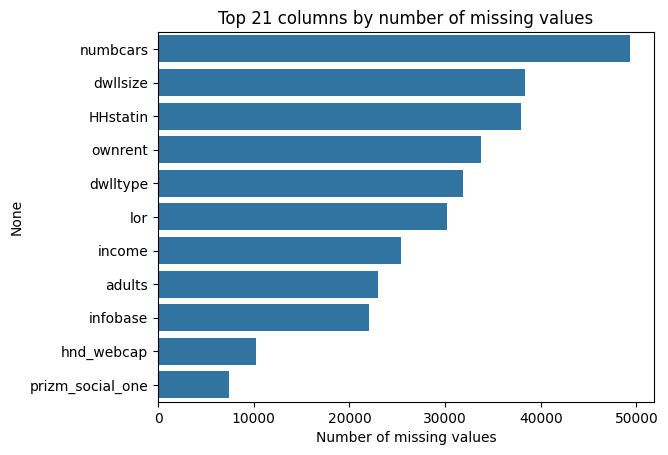

In [304]:
#Missing Value Analysis
missing_counts = df.isna().sum()

# Select top 11 features with most missing values
top_missing = missing_counts.sort_values(ascending=False).head(11)

#Visualize:
sns.barplot(
    x=top_missing.values,
    y=top_missing.index
)
plt.xlabel('Number of missing values')
plt.title('Top 21 columns by number of missing values')
plt.show()


**Purpose:**

Identify columns requiring imputation. <br>
Detect low-quality variables.

churn
0    50438
1    49562
Name: count, dtype: int64

churn
0    0.50438
1    0.49562
Name: proportion, dtype: float64


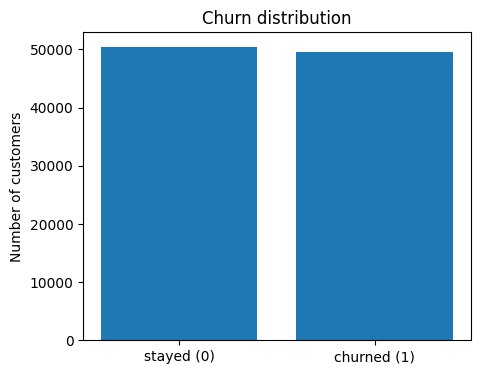

In [305]:
#Churn Distribution
# Counts and proportions
print(df['churn'].value_counts())
print()
print(df['churn'].value_counts(normalize=True))

# Bar chart
counts = df['churn'].value_counts().sort_index()
labels = ['stayed (0)', 'churned (1)']

plt.figure(figsize=(5, 4))
plt.bar(labels, counts.values)
plt.title('Churn distribution')
plt.ylabel('Number of customers')
plt.show()

**Observation:**

Stayed : 50,438 
<br>Churned : 49,562

The dataset is balanced.
<br>
Therefore:
Accuracy becomes a reliable evaluation metric.

Mean equipment age (stayed):  363.3 days
Mean equipment age (churned): 421.1 days


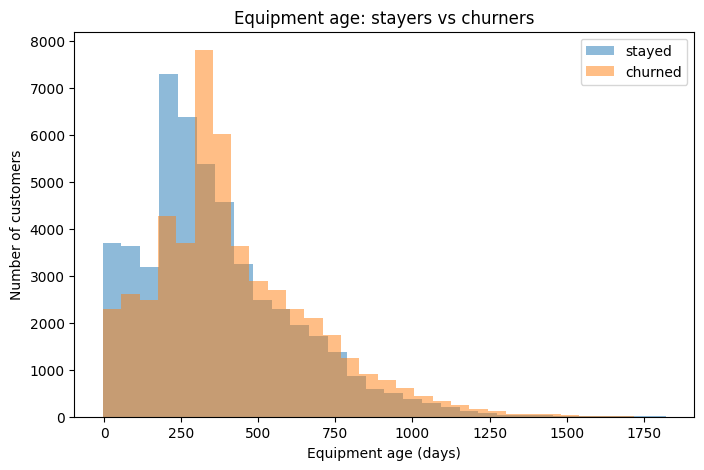

churn
0    50.438
1    49.562
Name: proportion, dtype: float64


In [306]:
#Feature:

# Split eqpdays into two groups based on churn
stayed = df[df['churn'] == 0]['eqpdays']
churned = df[df['churn'] == 1]['eqpdays']

# Compare the averages
print(f'Mean equipment age (stayed):  {stayed.mean():.1f} days')
print(f'Mean equipment age (churned): {churned.mean():.1f} days')

# Overlay the two distributions
plt.figure(figsize=(8, 5))
plt.hist(stayed, bins=30, alpha=0.5, label='stayed')
plt.hist(churned, bins=30, alpha=0.5, label='churned')
plt.xlabel('Equipment age (days)')
plt.ylabel('Number of customers')
plt.title('Equipment age: stayers vs churners')
plt.legend()
plt.show()

#Churn Percentage

churn_pct = (
    df["churn"]
    .value_counts(normalize=True)
    * 100
)

print(churn_pct)

Finding: Older devices strongly correlate with churn.

Business implication: Device upgrade programs may reduce churn.

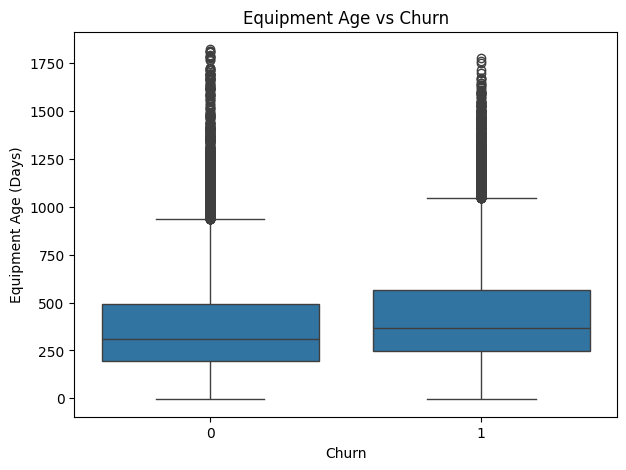

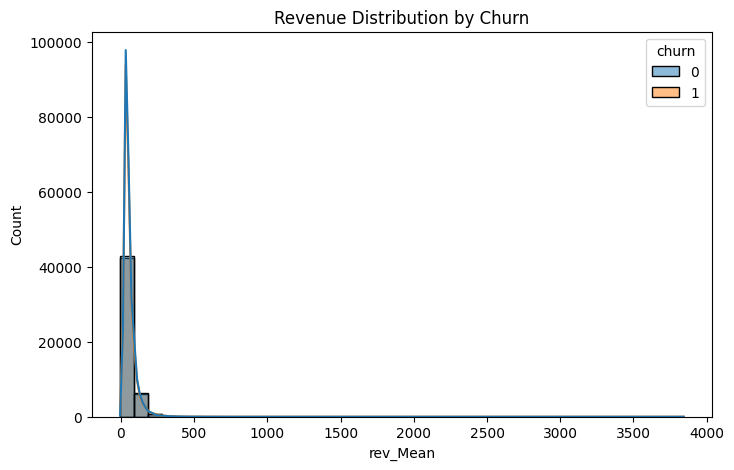

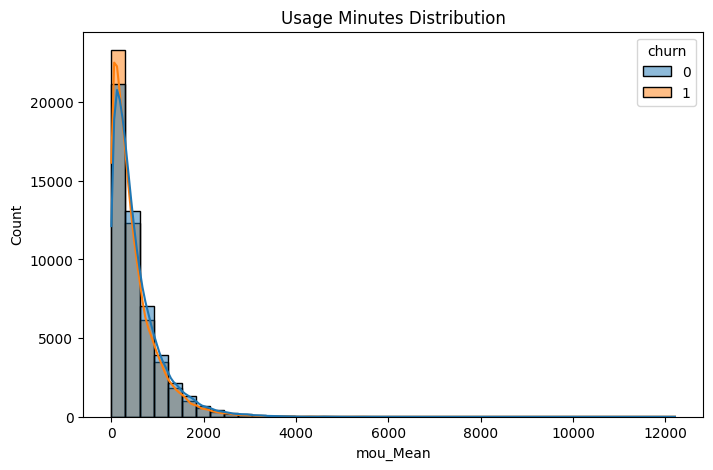

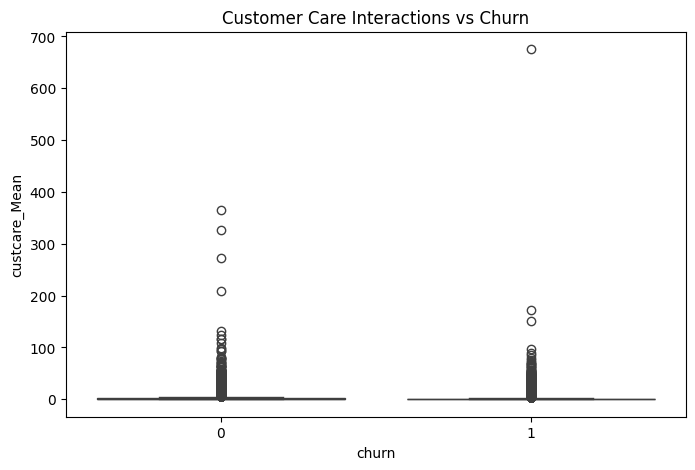

<Figure size 1600x1200 with 0 Axes>

In [307]:
# Feature Analysis:
#Equipment Age Analysis

eqp_analysis = (
    df.groupby("churn")["eqpdays"]
    .mean()
)

eqp_analysis

# Equipment Age Visualization

plt.figure(figsize=(7,5))

sns.boxplot(
    x="churn",
    y="eqpdays",
    data=df
)

plt.title("Equipment Age vs Churn")
plt.xlabel("Churn")
plt.ylabel("Equipment Age (Days)")

plt.show()

# Revenue Analysis

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="rev_Mean",
    hue="churn",
    kde=True,
    bins=40
)

plt.title("Revenue Distribution by Churn")

plt.show()

# Revenue by Churn

df.groupby("churn")["rev_Mean"].mean()

#- Usage Analysis

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="mou_Mean",
    hue="churn",
    kde=True,
    bins=40
)

plt.title("Usage Minutes Distribution")

plt.show()

# Customer Care Analysis

plt.figure(figsize=(8,5))

sns.boxplot(
    x="churn",
    y="custcare_Mean",
    data=df
)

plt.title("Customer Care Interactions vs Churn")

plt.show()

# Correlation Analysis

numeric_df = df.select_dtypes(
    include=np.number
)

corr_matrix = numeric_df.corr()

# Correlation Heatmap

plt.figure(figsize=(16,12))


plt.show()

**Data Preprocessing**
Remove Unique Identifier
Customer_ID provides no predictive value.

In [308]:
from sklearn.preprocessing import LabelEncoder

# Drop the ID column
df_clean = df.drop(columns=['Customer_ID'])

# Find all columns that are stored as text (object dtype)
object_cols = df_clean.select_dtypes(include='object').columns.tolist()
print('Columns to encode:', object_cols)

# Encode each categorical feature as integers
for col in object_cols:
    encoder = LabelEncoder()
    df_clean[col] = encoder.fit_transform(df_clean[col].astype(str))

print()
print('Shape after preprocessing:', df_clean.shape)
df_clean.head()

/tmp/ipykernel_2023099/972614641.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df_clean.select_dtypes(include='object').columns.tolist()


Columns to encode: ['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_webcap', 'ownrent', 'dwlltype', 'marital', 'infobase', 'HHstatin', 'dwllsize', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd']

Shape after preprocessing: (100000, 99)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,0,0.0,9,0,0,0,0,0,1,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,0,0.0,16,0,0,0,0,0,1,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,0,0.0,9,0,1,0,0,0,1,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,...,3,0.0,14,1,0,0,0,0,1,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,...,14,0.0,6,0,0,0,0,0,1,434.0


**Missing Value Imputation**

Purpose
Handles missing values.
What This Cell Does

Replaces missing categorical values with "Unknown".

Replaces missing numerical values with median values.
Verifies no missing values remain.

In [309]:
for col in df_clean.columns:

    if df_clean[col].dtype == "object":
        df_clean[col] = df_clean[col].fillna("Unknown")

    else:
        df_clean[col] = df_clean[col].fillna(
            df_clean[col].median()
        )

print("Missing Values Remaining:")
print(df_clean.isnull().sum().sum())

Missing Values Remaining:
0


**Encode Categorical Variables**

Purpose: Converts categorical variables into numeric format.

What This Cell Does

Identifies object columns.

Applies Label Encoding.

Stores encoders for future use.



In [310]:
object_cols = (
    df_clean
    .select_dtypes(include="object")
    .columns
)

label_encoders = {}

for col in object_cols:

    le = LabelEncoder()

    df_clean[col] = le.fit_transform(
        df_clean[col].astype(str)
    )

    label_encoders[col] = le

print("Encoding Complete")


Encoding Complete


In [311]:
#A preview table of data.

df_clean.head()

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,0,0.0,9,0,0,0,0,0,1,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,0,0.0,16,0,0,0,0,0,1,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,0,0.0,9,0,1,0,0,0,1,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,...,3,0.0,14,1,0,0,0,0,1,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,...,14,0.0,6,0,0,0,0,0,1,434.0


 **Feature and Target Selection**

Purpose: Separates predictors and target variable.

Assigns churn column to y.

Assigns remaining features to X.

In [312]:
y = df_clean["churn"]

X = df_clean.drop(
    "churn",
    axis=1
)

print(X.shape)
print(y.shape)

#Training and testing dataset shapes.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

# Bluilding the XGBoost Classifier Model
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric="logloss",
    random_state=42
)
# Train model - Learns patterns associated with churn.
#               -Builds decision trees internally.

model.fit(
    X_train,
    y_train
)

print("Model Training Complete")

y_pred = model.predict(X_test)

y_proba = model.predict_proba(
    X_test
)[:,1]

'''Accuracy Score
    -Measures overall prediction accuracy.
Compares predicted labels with actual labels.'''

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", round(accuracy*100,2), "%")


(100000, 98)
(100000,)


Training Shape : (70000, 98)
Testing Shape  : (30000, 98)
Model Training Complete
Accuracy: 63.57 %


 **Classification Report**

In [313]:

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.64      0.63      0.63     15131
           1       0.63      0.65      0.64     14869

    accuracy                           0.64     30000
   macro avg       0.64      0.64      0.64     30000
weighted avg       0.64      0.64      0.64     30000



**ROC AUC Score**

Measures ranking performance.

Calculates Area Under the ROC Curve.

In [314]:
roc_auc = roc_auc_score(
    y_test,
    y_proba
)

print("ROC AUC:", round(roc_auc,4))

ROC AUC: 0.6936


**Confusion Matrix**

Evaluates prediction outcomes.
Counts true positives, true negatives, false positives, and false negatives.

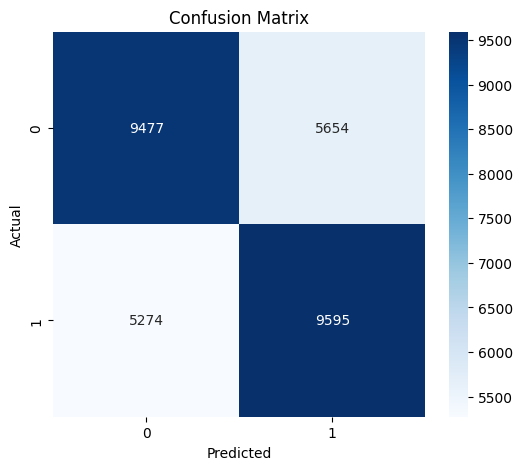

In [315]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**ROC Curve**

Visualizes model discrimination ability.

Computes ROC curve coordinates.

Plots true positive rate versus false positive rate.



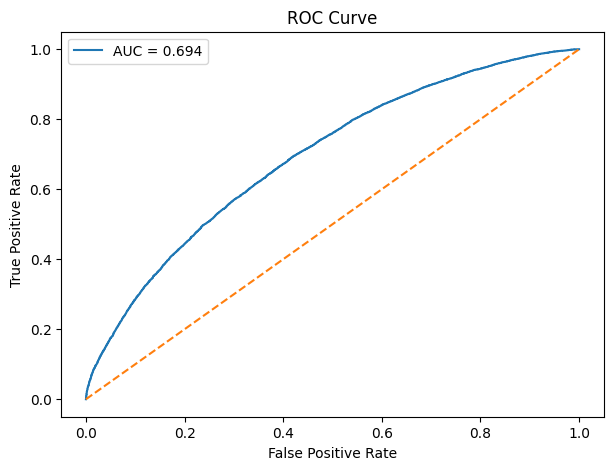

In [316]:
#ROC curve chart with AUC value.

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_proba
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

**Feature Importance**

<Figure size 1000x800 with 0 Axes>

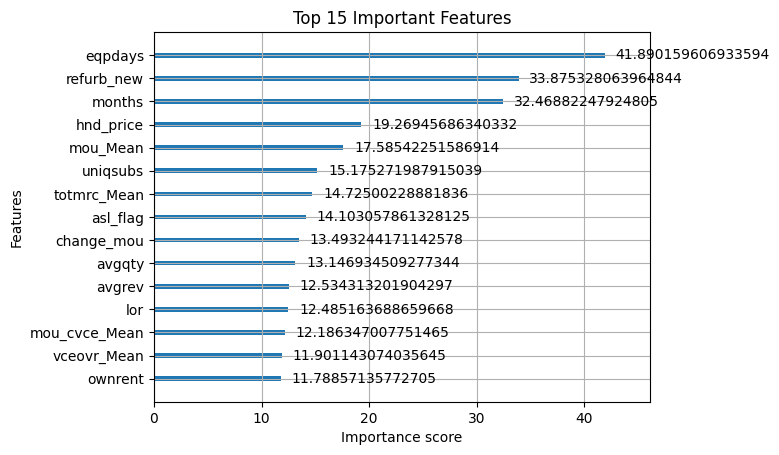

In [317]:
plt.figure(figsize=(10,8))

plot_importance(
    model,
    max_num_features=15,
    importance_type="gain"
)

plt.title("Top 15 Important Features")

plt.show()